# ENGR 1451/2451 — Weekly Assignment 1
**10 points**

This assignment focuses on four goals: basic Python expressions, working with a `pandas` DataFrame, calculating summary statistics, and visualizing data.

**Due:** See Canvas.

Complete the work directly in this notebook. Show your Python code and give brief written explanations where requested. Submit the completed notebook as directed in Canvas.

## What to hand in

Work this assignment with the **course tutor** in the class project. That is the AI help to use on this assignment, and it keeps the record for you — you do not write one yourself.

At the end of each working session, type **"make my record"** in the chat. Copy the block it produces and paste it into the **Session records** cell near the bottom of this notebook.

You do not have to finish in one sitting. To pick up later, start a new chat in the same project, say which assignment you are on and which problem you stopped at, and keep going. That session gives you its own block, which you paste under the previous one.

Records are not graded for correctness or for how much help you needed, and extra credit is given for a record that shows you attempted the problem. The code and the written answers still have to be yours.

## LE1-1. Python warm-up (1 pt)
Use Python as a calculator. In one code cell, show an example of:
- addition,
- subtraction,
- multiplication,
- division, and
- exponentiation.

In [2]:
# Your code here
A = 6
B = 7
add = A + B
subtract = A - B
product = A*B
quotient = A / B
power_result = A**B

print("if A = ",A," & B = ",B)
print("A + B = ",add)
print("A - B = ",subtract)
print("A * B = ",product)
print("A / B = ",quotient)
print("A^B = ",power_result)

if A =  6  & B =  7
A + B =  13
A - B =  -1
A * B =  42
A / B =  0.8571428571428571
A^B =  279936


## LE1-2. Iris data: structure, summary statistics, and visualization (6 pts)

A useful data-analysis workflow can be summarized as:
**question → data → cleaning → exploratory analysis → visualization → interpretation → communication → reproducible code**.

For this exercise, use the `iris.csv` file supplied with this assignment. Download it from Canvas and put it in a folder named `data` next to this notebook, so that the path `./data/iris.csv` works. The file contains measurements of sepal length/width and petal length/width for three iris species.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

iris = pd.read_csv("./iris.csv") #I changed the location of the iris data so I adjusted this line
iris = iris.drop(columns=["rownames"], errors="ignore")
iris.head()


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### A. Understand the data (2 pts)
Using Python, answer:
1. How many observations (rows) are in the dataset?
2. Which variables are numerical? Are they continuous or discrete?
3. Which variable is categorical, and what are its categories?
4. How many observations belong to each species?

**Answer:**

In [6]:
# Useful tools: iris.shape, iris.dtypes, iris.select_dtypes(),
# iris["Species"].unique(), iris["Species"].value_counts()

# Your code here
import numpy as np


#QUESTION 1
count_output = iris["Species"].count() #count rows using Species column, but any column would work
print("1. There are ",count_output," rows/observations in the dataset")

#QUESTION 2
datatypes = iris.dtypes
first_datatype = datatypes.iloc[[1][0]]  #extract datatype that applies to the flower measurements
second_datatype = datatypes.iloc[[4][0]] #extract datatype that applies to the Species column

print("2. Sepal.Length Sepal.Width Petal.Length and Petal.Width are ",first_datatype,", so they are numerical")
print("   Species is ",second_datatype,", and it is not numerical")


#see if data is discrete or continuous
#This is based off of the fact that if data points are integers, it is probably a discrete measurement
#and if they are a decimal, it is probably continuous with a degree of precision
sepal_length_array = np.array(iris["Sepal.Length"])
trunc_sepal_length_array = np.trunc(sepal_length_array)
diff = np.subtract(sepal_length_array,trunc_sepal_length_array) #removes numbers before decimal point
print("Sepal.Length")
if np.all(diff == 0): #tests if integer
    print("  is probably discrete")
else:
    print("  is probably continuous")

sepal_width_array = np.array(iris["Sepal.Width"])
trunc_sepal_width_array = np.trunc(sepal_width_array)
diff = np.subtract(sepal_width_array,trunc_sepal_width_array)
print("Sepal.Width")
if np.all(diff == 0): #tests if integer
    print("  is probably discrete")
else:
    print("  is probably continuous")      

petal_width_array = np.array(iris["Petal.Width"])
trunc_petal_width_array = np.trunc(petal_width_array)
diff = np.subtract(petal_width_array,trunc_petal_width_array)
print("Petal.Width")
if np.all(diff == 0): #tests if integer
    print("  is probably discrete")
else:
    print("  is probably continuous")
    
petal_length_array = np.array(iris["Petal.Length"])
trunc_petal_length_array = np.trunc(petal_length_array)
diff = np.subtract(petal_length_array,trunc_petal_length_array)
print("Petal.Length")
if np.all(diff == 0): #tests if integer
    print("  is probably discrete")
else:
    print("  is probably continuous")
    
#QUESTION 3
    
species_list = iris["Species"].unique()
print("3. The species variable is categorical. Its categories are:")
for i in range(0,3):  #hard coded loops because I'm not sure where to get the size from
    print("    ",species_list[i])
    

#QUESTION 4
obs_number = iris["Species"].value_counts()
print("4.")
for i in range(0,3):
    print("    ",species_list[i]," has ",obs_number.iloc[[i][0]]," observations")

1. There are  150  rows/observations in the dataset
2. Sepal.Length Sepal.Width Petal.Length and Petal.Width are  float64 , so they are numerical
   Species is  object , and it is not numerical
Sepal.Length
  is probably continuous
Sepal.Width
  is probably continuous
Petal.Width
  is probably continuous
Petal.Length
  is probably continuous
3. The species variable is categorical. Its categories are:
     setosa
     versicolor
     virginica
4.
     setosa  has  50  observations
     versicolor  has  50  observations
     virginica  has  50  observations


### B. Analyze *versicolor* (2 pts)
1. Create a DataFrame containing only `versicolor` flowers.
2. Report the mean and median of each numerical variable.
3. Briefly explain why a single overall mean for all three species can be misleading.

**Answer:**

In [6]:
# Your code here
versicolor = iris.loc[iris["Species"] == "versicolor"] #filter by versicolor species
print("for versicolor, means are")
print(versicolor[["Sepal.Length", "Sepal.Width", "Petal.Length", "Petal.Width"]].mean())
print("for versicolor, medians are")
print(versicolor[["Sepal.Length", "Sepal.Width", "Petal.Length", "Petal.Width"]].median())
print("for all species combined, means are")
print(iris[["Sepal.Length", "Sepal.Width", "Petal.Length", "Petal.Width"]].mean())
print("for all species combined, medians are")
print(iris[["Sepal.Length", "Sepal.Width", "Petal.Length", "Petal.Width"]].median())

print("The species have different means for their measurements and expressing them combined can imply that all species have the same measure of center")


for versicolor, means are
Sepal.Length    5.936
Sepal.Width     2.770
Petal.Length    4.260
Petal.Width     1.326
dtype: float64
for versicolor, medians are
Sepal.Length    5.90
Sepal.Width     2.80
Petal.Length    4.35
Petal.Width     1.30
dtype: float64
for all species combined, means are
Sepal.Length    5.843333
Sepal.Width     3.057333
Petal.Length    3.758000
Petal.Width     1.199333
dtype: float64
for all species combined, medians are
Sepal.Length    5.80
Sepal.Width     3.00
Petal.Length    4.35
Petal.Width     1.30
dtype: float64
The species have different means for their measurements and expressing them combined can imply that all species have the same measure of center


### C. Visualize the iris data (2 pts)
Create a scatter plot of **Petal.Length** versus **Petal.Width** for all flowers in the iris dataset.

1. Put `Petal.Width` on the x-axis and `Petal.Length` on the y-axis.
2. Color the points by species so the three species can be compared.
3. Label both axes and include a legend.
4. Briefly describe the main pattern you see in the plot.

**Answer:**

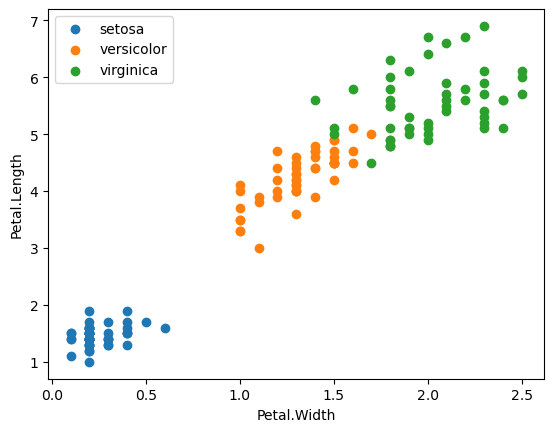

Setosa has non overlapping petal width and length but all species have distinctly different centers for these measurements.


In [9]:
# Your visualization code here

for species in iris["Species"].unique():
    subset = iris.loc[iris["Species"] == species]
    plt.scatter(subset["Petal.Width"], subset["Petal.Length"], label=species)

plt.xlabel("Petal.Width")
plt.ylabel("Petal.Length")
plt.legend()
plt.show()
print("Setosa has non overlapping petal width and length but all species have distinctly different centers for these measurements.")

## LE1-3. Distribution shape and appropriate statistics (3 pts)

For each situation, state:
1. expected shape: **symmetric, right-skewed, or left-skewed**;
2. better measure of center: **mean or median**;
3. better measure of spread: **standard deviation or IQR**;
4. a brief reason.

Each case is worth 0.75 pt.

| Case | Situation |
|---|---|
| **a** | House prices: Q1 = \$350k, median = \$450k, Q3 = \$1.0M, with a meaningful number above \$6M |
| **b** | House prices: Q1 = \$300k, median = \$600k, Q3 = \$900k, with very few above \$1.2M |
| **c** | Weekly alcoholic drinks among students: most consume 0, while a few consume many |
| **d** | Scores on a straightforward 100-point quiz: most students score in the 80s and 90s, with a few much lower scores |

**Answers:**

**a.**
1. Very right-skewed. Median is much closer to Q1. Using 3\*IQR+Q3 extreme outlier rule, 3\*(1-0.35) + 1 = 2.95 thus houses above 6M contribute to right-skew.
2. Because of right skew with extreme outliers, median is better measure of center.
3. Since median reflects center better, IQR represents spread better because it contains 50 percent of the data, while standard deviation is affected by outliers.
4. Median and IQR better represent center and spread for most of the data. But the presence of the extreme outliers is 'part of the story'.

**b.**
1. Using 1.5\*IQR+Q3 outlier rule, 1.5\*(0.9-0.3) + 0.9 = 1.8M. Thus the few houses above 1.2M are not outliers. Also median - Q1 = Q3 - median so the data is probably symmetric.
2. With the given data, mean or median could be a good measure of center.
3. Since the data is symmetric, standard deviation or IQR could show spread.
4. With no outliers (assuming none below Q1), the data is probably symmetric and mean and standard deviation can be used.
**c.**
1. Data will be right skewed. On a histogram, it may look bimodal with the largest bar at 0 drinks and a smaller bar at a higher number of drinks with little data in between.
2. Median is a better measure of center to evaulate the number of drinks for most students. Mean will be higher because it factors in the outlier students who have many drinks.
3. Since median is the used measure of center, IQR should be used for spread with outliers identified as well.
4. With the outliers, median and IQR should be used.

**d.**
1. Since the outliers are low scores, the data will be extremely left skewed since most of the scores are high as well.
2. Median is a better measure of center because it is left skewed.
3. Since median is used, IQR will be a better show of spread. Standard deviation will also be affected by low scores like the mean.
4. If the much lower scores are 50 and below, median and IQR should be used because of the skew in the data.

## Session records

At the end of each working session, type **"make my record"** in the chat and paste the block it produces into the cell below. If you work across several sessions, paste each new block underneath the previous one.

Assignments are not graded for correctness or for how much help you needed, and extra credit is given for a record that shows you attempted the problem. They are read to find out which steps are hardest, and used to improve the course.

<!-- Paste your session record blocks in this cell, one after another. -->
{
  "schema_version": "engr-tutor-export-2",
  "assignment": "LE01",
  "export_n": 1,
  "session_date": "2026-09-08",
  "messages": [
    {"i": 1, "who": "student", "text": "is this correct for q1: # Your code here\nA = 6\nB = 7\nadd = A + B\nsubtract = A - B\nproduct = A*B\nquotient = A / B\npower_result = A**B\nprint(\"if A = \",A,\" & B = \",B)\nprint(\"A + B = \",add)\nprint(\"A - B = \",subtract)\nprint(\"A * B = \",product)\nprint(\"A / B = \",quotient)\nprint(\"A^B = \",power_result)", "code": true},
    {"i": 2, "who": "tutor", "text": "This covers all five operations correctly: `+`, `-`, `*`, `/`, and `**` for exponentiation, and using `print()` on separate lines like you did means all five results will actually display — no \"only the last one shows\" problem here.\n\nOne small thing worth a look: your last print line says \"A^B = \", but `^` isn't the exponentiation operator in Python (it's actually bitwise XOR if you ever use it directly). You used `**` correctly in the calculation itself, so the math is right — it's just the label text that says `^` instead of `**`. Might be worth matching your label to what you actually typed in the code.\n\nNice clean warm-up otherwise. Want to keep going to LE1-2, or is there anything else on this one first?"},
    {"i": 3, "who": "student", "text": "question 2 check: # Useful tools: iris.shape, iris.dtypes, iris.select_dtypes(),\n# iris[\"Species\"].unique(), iris[\"Species\"].value_counts()\n# Your code here\nimport numpy as np\n#QUESTION 1\ncount_output = iris[\"Species\"].count() #count rows using Species column, but any column would work\nprint(\"1. There are \",count_output,\" rows/observations in the dataset\")\n#QUESTION 2\ndatatypes = iris.dtypes\nfirst_datatype = datatypes.iloc[[1][0]]  #extract datatype that applies to the flower measurements\nsecond_datatype = datatypes.iloc[[4][0]] #extract datatype that applies to the Species column\nprint(\"2. Sepal.Length Sepal.Width Petal.Length and Petal.Width are \",first_datatype,\", so they are numerical\")\nprint(\"   Species is \",second_datatype,\", and it is not numerical\")\n#see if data is discrete or continuous\n#This is based off of the fact that if data points are integers, it is probably a discrete measurement\n#and if they are a decimal, it is probably continuous with a degree of precision\nsepal_length_array = np.array(iris[\"Sepal.Length\"])\ntrunc_sepal_length_array = np.trunc(sepal_length_array)\ndiff = np.subtract(sepal_length_array,trunc_sepal_length_array) #removes numbers before decimal point\nprint(\"Sepal.Length\")\nif np.all(diff == 0): #tests if integer\n    print(\"  is probably discrete\")\nelse:\n    print(\"  is probably continuous\")\nsepal_width_array = np.array(iris[\"Sepal.Width\"])\ntrunc_sepal_width_array = np.trunc(sepal_width_array)\ndiff = np.subtract(sepal_width_array,trunc_sepal_width_array)\nprint(\"Sepal.Width\")\nif np.all(diff == 0): #tests if integer\n    print(\"  is probably discrete\")\nelse:\n    print(\"  is probably continuous\")      \npetal_width_array = np.array(iris[\"Petal.Width\"])\ntrunc_petal_width_array = np.trunc(petal_width_array)\ndiff = np.subtract(petal_width_array,trunc_petal_width_array)\nprint(\"Petal.Width\")\nif np.all(diff == 0): #tests if integer\n    print(\"  is probably discrete\")\nelse:\n    print(\"  is probably continuous\")\n    \npetal_length_array = np.array(iris[\"Petal.Length\"])\ntrunc_petal_length_array = np.trunc(petal_length_array)\ndiff = np.subtract(petal_length_array,trunc_petal_length_array)\nprint(\"Petal.Length\")\nif np.all(diff == 0): #tests if integer\n    print(\"  is probably discrete\")\nelse:\n    print(\"  is probably continuous\")\n    \n#QUESTION 3\n    \nspecies_list = iris[\"Species\"].unique()\nprint(\"3. The species variable is categorical. Its categories are:\")\nfor i in range(0,3):  #hard coded loops because I'm not sure where to get the size from\n    print(\"    \",species_list[i])\n    \n#QUESTION 4\nobs_number = iris[\"Species\"].value_counts()\nprint(\"4.\")\nfor i in range(0,3):\n    print(\"    \",species_list[i],\" has \",obs_number.iloc[[i][0]],\" observations\")", "code": true},
    {"i": 4, "who": "tutor", "text": "Good, you're being thorough here — let's go through it piece by piece.\n\n**Question 1 (count):** `iris[\"Species\"].count()` works, assuming no missing values in that column. Fine.\n\n**Question 2 (numerical variables and dtypes):** Your `.iloc[[1][0]]` is a strange way to write `.iloc[1]` — `[1][0]` is just a Python list literal being indexed, which evaluates to `1`, so it's doing nothing extra. It works, but it's worth knowing `datatypes.iloc[1]` says the same thing more directly.\n\nThe bigger thing to notice: you're grabbing the dtype of one numeric column (index 1, `Sepal.Width`) and using it to represent all four measurement columns. That happens to work here because all four numeric columns share the same dtype, but your code never actually checks that — it just assumes it. Might be worth asking yourself: is there a way to confirm all four numeric columns share a dtype, rather than sampling one and hoping? `iris.select_dtypes(include=\"number\")` (mentioned right on the assignment sheet) would show you all of them at once, if you want to look at that.\n\n**Discrete vs. continuous check:** Clever approach — truncating and comparing to the original to see if everything is a whole number. It'll correctly tell you these are continuous, since sepal/petal measurements have decimal precision. One thing to sit with: this test works for this dataset, but the real reason these are continuous isn't \"the code found decimals\" — it's that length and width are physical measurements that could take any value in a range, limited only by how precisely you measure them. Worth having that reasoning in your head even though the code check is a nice practical shortcut.\n\n**Question 3 & 4 — your `range(0,3)`:** You flagged that you weren't sure how to get the size instead of hardcoding it — good instinct to notice. Two ways: `len(species_list)` gives you the length of that array, or since `species_list` came from `.unique()`, you could also just use `for species in species_list:` directly instead of looping over indices at all, and skip the size question entirely. Want me to show how that loop form works?\n\nEverything else in the logic checks out — nice work reasoning through the discrete/continuous distinction with actual code instead of just eyeballing it. What do you want to do about the hardcoded 3, and are you ready to move to LE1-2B?"},
    {"i": 5, "who": "student", "text": "for part two : # Your code here\nversicolor = iris.loc[iris[\"Species\"] == \"versicolor\"] #filter by versicolor species\nprint(\"for versicolor, means are\")\nprint(versicolor[[\"Sepal.Length\", \"Sepal.Width\", \"Petal.Length\", \"Petal.Width\"]].mean())\nprint(\"for versicolor, medians are\")\nprint(versicolor[[\"Sepal.Length\", \"Sepal.Width\", \"Petal.Length\", \"Petal.Width\"]].median())\nprint(\"for all species combined, means are\")\nprint(iris[[\"Sepal.Length\", \"Sepal.Width\", \"Petal.Length\", \"Petal.Width\"]].mean())\nprint(\"for all species combined, medians are\")\nprint(iris[[\"Sepal.Length\", \"Sepal.Width\", \"Petal.Length\", \"Petal.Width\"]].median())", "code": true},
    {"i": 6, "who": "tutor", "text": "Good filter, and the mean/median calls on the four columns are exactly right — that's parts 1 and 2 handled cleanly.\n\nNice touch pulling the overall (all-species) mean and median too, even though the prompt didn't explicitly ask you to compute that — it sets you up well for part 3.\n\nSo: part 3 asks you to explain why a single overall mean across all three species can be misleading. You've now got the numbers sitting right in front of you — versicolor's mean and median next to the pooled mean and median. What do you notice when you compare them? What is the pooled mean actually a blend of, and what does that blending hide?"},
    {"i": 7, "who": "student", "text": "question 4 : **Answers:**\n**a.**\n1. Very right-skewed. Median is much closer to Q1. Using 3*IQR+Q3 extreme outlier rule, 3*(1-0.35) + 1 = 2.95 thus houses above 6M contribute to right-skew.\n2. Because of right skew with extreme outliers, median is better measure of center.\n3. Since median reflects center better, IQR represents spread better because it contains 50 percent of the data, while standard deviation is affected by outliers.\n4. Median and IQR better represent center and spread for most of the data. But the presence of the extreme outliers is 'part of the story'.\n**b.**\n1. Using 1.5*IQR+Q3 outlier rule, 1.5*(0.9-0.3) + 0.9 = 1.8M. Thus the few houses above 1.2M are not outliers. Also median - Q1 = Q3 - median so the data is probably symmetric.\n2. With the given data, mean or median could be a good measure of center.\n3. Since the data is symmetric, standard deviation or IQR could show spread.\n4. With no outliers (assuming none below Q1), the data is probably symmetric and mean and standard deviation can be used.\n**c.**\n1. Data will be right skewed. On a histogram, it may look bimodal with the largest bar at 0 drinks and a smaller bar at a higher number of drinks with little data in between.\n2. Median is a better measure of center to evaulate the number of drinks for most students. Mean will be higher because it factors in the outlier students who have many drinks.\n3. Since median is the used measure of center, IQR should be used for spread with outliers identified as well.\n4. With the outliers, median and IQR should be used.\n**d.**\n1. Since the outliers are low scores, the data will be extremely left skewed since most of the scores are high as well.\n2. Median is a better measure of center because it is left skewed.\n3. Since median is used, IQR will be a better show of spread. Standard deviation will also be affected by low scores like the mean.\n4. If the much lower scores are 50 and below, median and IQR should be used because of the skew in the data."},
    {"i": 8, "who": "tutor", "text": "This is thorough — you're actually running the outlier-rule numbers rather than eyeballing it, which is exactly the kind of check that makes a verdict solid.\n\na. Shape, center, and spread verdicts are all right, and your outlier-rule math checks out: 3xIQR above Q3 lands around 2.95M, so the houses above 6M really are extreme outliers pulling the shape right. Reasoning for 1-3 holds together well. Point 4 is a nice touch — naming that the outliers are part of the story rather than something to just discard.\n\nb. Your symmetry check (median minus Q1 equals Q3 minus median) is a good instinct, and the 1.5xIQR math is right — 1.8M — so those few houses above 1.2M aren't outliers by that rule. Verdict and reasoning are solid.\n\nc. Right-skewed is correct, but look again at \"bimodal\" — a bimodal distribution has two separate peaks with a dip between them. What you're describing (a big spike at 0, then a thinning tail of higher values) doesn't really have a second peak, it's more like one mode at zero with a long right tail. Does \"bimodal\" still fit what you mean, or would a different word describe the shape you're picturing? Center and spread reasoning (2 and 3) are good.\n\nd. Left-skewed, median, IQR — all correct, and your point about standard deviation being pulled by the low scores just like the mean is the right idea.\n\nStrong set overall. Want to take another look at the word choice in (c), or are you happy with how it reads once you reconsider it?"},
    {"i": 9, "who": "student", "text": "how do i separate by species for Q2 part 3? I have this so far: # Your visualization code here\niris.plot.scatter([\"Petal.Width\"],[\"Petal.Length\"])", "code": true},
    {"i": 10, "who": "tutor", "text": "Good start — you've got the axes right (Petal.Width on x, Petal.Length on y), though you don't need the brackets around the column names: `iris.plot.scatter(\"Petal.Width\", \"Petal.Length\")` works with plain strings. `.plot.scatter()` doesn't have a built-in \"color by category\" option the way some plotting libraries do, so the usual trick is to draw one species at a time, each as its own separate scatter call, and give each one a `label=`.\n\nHere's the idea on a made-up example. Say you had a frame of students with a height, a weight, and a class_year column with values freshman, sophomore, senior:\n\n```python\nimport matplotlib.pyplot as plt\n\nfor year in students[\"class_year\"].unique():\n    subset = students.loc[students[\"class_year\"] == year]\n    plt.scatter(subset[\"weight\"], subset[\"height\"], label=year)\n\nplt.xlabel(\"Weight\")\nplt.ylabel(\"Height\")\nplt.legend()\nplt.show()\n```\n\nWhat's happening: `students[\"class_year\"].unique()` gives you the distinct group names to loop over. Inside the loop, `students.loc[students[\"class_year\"] == year]` filters down to just that group's rows. Each `plt.scatter()` call plots only that subset, and matplotlib gives each call its own color automatically since they're separate calls. The `label=year` is what `plt.legend()` later reads to build the legend — without a label on each call, the legend has nothing to show.\n\nNotice this uses `plt.scatter` (plain matplotlib) rather than `iris.plot.scatter` (the pandas shortcut) — once you're drawing multiple groups on the same axes, it's easier to work with plt.scatter directly than to fight the pandas wrapper.\n\nWant to try wiring this loop to your iris frame, using Species in place of class_year?"},
    {"i": 11, "who": "student", "text": "make my record"}
  ],
  "events": [
    {"i": 1, "part": "1-1", "type": "code"},
    {"i": 3, "part": "1-2A", "type": "code"},
    {"i": 5, "part": "1-2B", "type": "code"},
    {"i": 7, "part": "1-3", "type": "code"},
    {"i": 9, "part": "1-2C", "type": "code"},
    {"i": 10, "part": "1-2C", "type": "explain"}
  ],
  "parts": [
    {"part": "1-1", "exchanges": 1, "max_tier": 1, "passed": true},
    {"part": "1-2A", "exchanges": 1, "max_tier": 2, "passed": true},
    {"part": "1-2B", "exchanges": 1, "max_tier": 1, "passed": false},
    {"part": "1-3", "exchanges": 1, "max_tier": 1, "passed": false},
    {"part": "1-2C", "exchanges": 1, "max_tier": 2, "passed": false}
  ],
  "tutor_assessment": [
    "The longest sticking point was LE1-2C, on separating the scatter by species — the student had the axes right but no path to per-group coloring, so a Tier 2 explanation (naming the loop-and-label technique with a generic example) was given; LE1-2B3 and the LE1-3 wording question on 'bimodal' in case (c) were also left open for the student to finish in their own words.",
    "No release valve or 'I got it, let's move on' was invoked this session, so there is no instance of that kind to flag."
  ]
}

## Before you submit

1. **Restart Kernel and Run All Cells** and confirm every cell ran without errors.
2. Confirm your plot and printed values are visible in the saved file.
3. Confirm your session record blocks are pasted into the cell above.
4. Save the notebook, then upload the `.ipynb` to Canvas.

### Reference
Adapted from exercises in *OpenIntro Statistics*, 4th ed., and the original course assignment.